In [2]:
import pandas as pd
import seaborn as sns
import numpy as np

In [3]:
! pip install fastf1


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 58.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.9 MB/s eta 0:00:00


In [4]:
import fastf1

In [5]:
from fastf1 import plotting

In [7]:
session=fastf1.get_session(2024,"Bahrain","R")

req         WARNING 	DEFAULT CACHE ENABLED! (24.0 KB) /root/.cache/fastf1


In [9]:
session.load()

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.2]
INFO:fastf1.fastf1.core:Loading data for Bahrain Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_d

In [10]:
session_laptime=session.laps.pick_fastest()

In [11]:
alo_lap=session.laps[session.laps["Driver"]=="ALO"].pick_fastest()

In [13]:
tel=alo_lap.get_telemetry()

In [14]:
# Show key data
print(f"Driver: {alo_lap['Driver']}")
print(f"Lap time: {alo_lap['LapTime']}")
print(f"Telemetry columns: {tel.columns.tolist()}")

Driver: ALO
Lap time: 0 days 00:01:34.199000
Telemetry columns: ['Date', 'SessionTime', 'DriverAhead', 'DistanceToDriverAhead', 'Time', 'RPM', 'Speed', 'nGear', 'Throttle', 'Brake', 'DRS', 'Source', 'Distance', 'RelativeDistance', 'Status', 'X', 'Y', 'Z']


In [15]:
import matplotlib.pyplot as plt

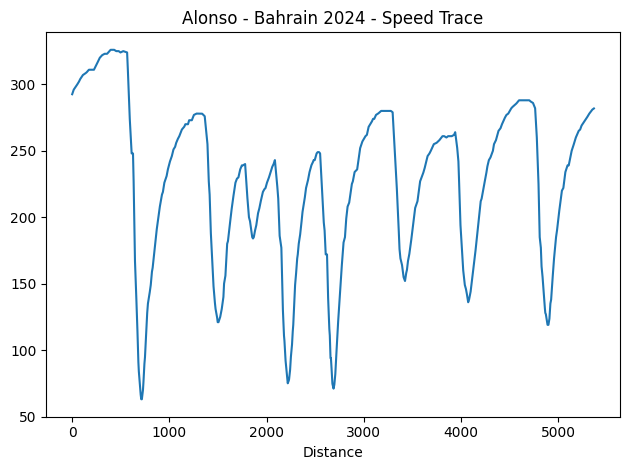

In [20]:
fig,ax=plt.subplots()
ax.plot(tel['Distance'],tel['Speed'])
ax.set_xlabel("Distance")
ax.set_label("Speed (km/h)")
ax.set_title(f"Alonso - Bahrain 2024 - Speed Trace")
plt.tight_layout()
plt.show()

In [21]:
tel.to_csv("Alonso_bahrain_2024.csv",index=False)